# Target Definition

**Proyecto:** Predicción de subempleo por insuficiencia de horas – EPEN 2024 (INEI Perú)  
**Notebook:** Definición formal de la variable objetivo `target_subempleo_horas`.

## Objetivo del notebook

Este notebook tiene como objetivo:

1. Definir formalmente la **variable objetivo** del proyecto.
2. Justificar la elección del target a partir de la estructura del cuestionario EPEN 2024.
3. Construir la variable binaria `target_subempleo_horas` a partir de `P209H`.
4. Validar y documentar la distribución inicial del target.
5. Identificar variables con riesgo de *data leakage* que deben excluirse del modelo.
6. Guardar el dataset filtrado con el target definido para uso en etapas posteriores.

## 1. Contexto de la problemática

El presente proyecto **no** busca predecir si una persona está ocupada o desocupada en términos del desempleo abierto.

El objetivo es identificar a **trabajadores que, pese a tener empleo, trabajan menos horas de las que desean** y están disponibles para trabajar más. Esta situación se conoce como **subempleo por insuficiencia de horas** o **inserción laboral insuficiente**.

### ¿Cuándo se considera que una persona es subempleada por horas?

Según el cuestionario EPEN 2024 (módulo de ocupación), la variable `P209H` sintetiza las condiciones `C333` y `C334`:

- **`C333`**: ¿La semana pasada, ¿quería trabajar más horas?
- **`C334`**: ¿Estaba disponible para trabajar más horas?

| `P209H` | Condición | Significado |
|---|---|---|
| **1** | `C333 = Sí` **y** `C334 = Sí` | La persona quería y podía trabajar más horas → **Subempleada por horas** |
| **2** | No cumple ambas condiciones | → **No subempleada por horas** |

Esta variable es la base del **target binario** que se construirá en este notebook.

In [1]:
%pip install pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 2. Carga de la base original

In [3]:
NOTEBOOK_DIR = os.getcwd()
PROJECT_DIR  = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
RAW_PATH     = os.path.join(PROJECT_DIR, '01_raw_data', '250806 EPEN2024.xlsx')

print(f'Ruta del archivo: {RAW_PATH}')
print(f'Existe:           {os.path.exists(RAW_PATH)}')

# Inspeccionar hojas disponibles
xl = pd.ExcelFile(RAW_PATH)
print(f'\nHojas disponibles: {xl.sheet_names}')

# Cargar la primera hoja
df_raw = xl.parse(xl.sheet_names[0])
print(f'\nDimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
df_raw.head(3)

Ruta del archivo: g:\Mi unidad\UP - Ingeniería de la información\Semestre IX\Machine Learning\TrabajoFinal\clonProyecto\ML_PROYECTO_26_1\ml_project\01_raw_data\250806 EPEN2024.xlsx
Existe:           True

Hojas disponibles: ['250806 EPEN2024']

Dimensiones: 52,251 filas × 132 columnas


,ANIO,MES,CONGLOMERADO,MUESTRA,SELVIV,HOGAR,REGION,LLAVE_PANEL,ESTRATO,C201,...,D350,D351_T,INGTOT,INGTOTP,ingtrabw,RESIDENT,fa_ond24,fa_efm24,fa_amj24,fa_jas24
0,2024,10,18117,2,61,1,1,2.024102e+17,1,1,...,,,1367,1367,1367,1,700.400712,NaN,NaN,NaN
1,2024,10,18117,2,61,1,1,2.024102e+17,1,2,...,,,1534,1534,1534,1,700.400712,NaN,NaN,NaN
2,2024,10,18117,2,61,1,1,2.024102e+17,1,3,...,,,,,,1,,NaN,NaN,NaN


## 3. Verificación de variables necesarias

In [4]:
VARS_NECESARIAS = ['RESIDENT', 'C208', 'OCUP300', 'P209H', 'C333', 'C334']

print('Verificación de variables necesarias:\n')
print(f'{"Variable":<12} {"Presente":<10} {"Dtype":<15} {"Nulos":>8}')
print('-' * 50)
for v in VARS_NECESARIAS:
    presente = v in df_raw.columns
    dtype    = str(df_raw[v].dtype) if presente else '—'
    nulos    = int(df_raw[v].isna().sum()) if presente else -1
    print(f'{v:<12} {"✓" if presente else "✗":<10} {dtype:<15} {nulos:>8,}')

Verificación de variables necesarias:

Variable     Presente   Dtype              Nulos
--------------------------------------------------
RESIDENT     ✓          int64                  0
C208         ✓          object                 0
OCUP300      ✓          object                 0
P209H        ✓          object                 0
C333         ✓          object                 0
C334         ✓          object                 0


## 4. Universo analítico

Para construir el target, primero se delimita el universo de análisis. Solo tiene sentido clasificar como subempleado o no subempleado a personas que cumplan **todas** las siguientes condiciones:

| Filtro | Variable | Condición | Justificación |
|---|---|---|---|
| Residentes habituales | `RESIDENT` | == 1 | La encuesta distingue residentes habituales de visitantes. El análisis se centra en los primeros. |
| Edad mínima | `C208` | >= 14 | El módulo de empleo del EPEN se aplica a personas de 14 años a más. |
| Personas ocupadas | `OCUP300` | == 1 | El subempleo por horas solo aplica a quienes están trabajando efectivamente. |
| Respuesta válida en P209H | `P209H` | en {1, 2} | Solo se consideran las dos respuestas válidas del ítem (1 = subempleado, 2 = no subempleado). |

In [5]:
# Convertir columnas que pueden venir como string desde Excel
df_raw['C208_num']    = pd.to_numeric(df_raw['C208'], errors='coerce')
df_raw['OCUP300_num'] = pd.to_numeric(df_raw['OCUP300'].astype(str).str.strip(), errors='coerce')
df_raw['P209H_num']   = pd.to_numeric(df_raw['P209H'].astype(str).str.strip(),   errors='coerce')

mask = (
    (df_raw['RESIDENT']    == 1) &
    (df_raw['C208_num']    >= 14) &
    (df_raw['OCUP300_num'] == 1) &
    (df_raw['P209H_num'].isin([1, 2]))
)

df_target = df_raw[mask].copy()

n_total  = df_raw.shape[0]
n_univ   = df_target.shape[0]
print(f'Total de registros en la base original:  {n_total:,}')
print(f'Registros en el universo analítico:       {n_univ:,}')
print(f'Proporción del universo:                  {n_univ/n_total*100:.1f}%')
df_target[['RESIDENT', 'C208_num', 'OCUP300_num', 'P209H_num']].head()

Total de registros en la base original:  52,251
Registros en el universo analítico:       24,054
Proporción del universo:                  46.0%


,RESIDENT,C208_num,OCUP300_num,P209H_num
0,1,60.0,1.0,2.0
1,1,49.0,1.0,1.0
3,1,52.0,1.0,2.0
4,1,51.0,1.0,2.0
5,1,43.0,1.0,2.0


## 5. Definición de la variable objetivo

La variable objetivo se construye a partir de `P209H` mediante la siguiente recodificación:

| `P209H` | `target_subempleo_horas` | Significado |
|---|---|---|
| 1 | **1** | Subempleado por insuficiencia de horas |
| 2 | **0** | No subempleado por horas |

In [6]:
df_target['target_subempleo_horas'] = df_target['P209H_num'].map({1: 1, 2: 0})

print('Recodificación aplicada:')
print(df_target['target_subempleo_horas'].value_counts().sort_index()
      .rename({0: 'No subempleado (0)', 1: 'Subempleado (1)'}))

Recodificación aplicada:
target_subempleo_horas
No subempleado (0)    18064
Subempleado (1)        5990
Name: count, dtype: int64


## 6. Distribución del target

 Clase              Significado  Conteo Porcentaje
     0 No subempleado por horas   18064      75.1%
     1    Subempleado por horas    5990      24.9%


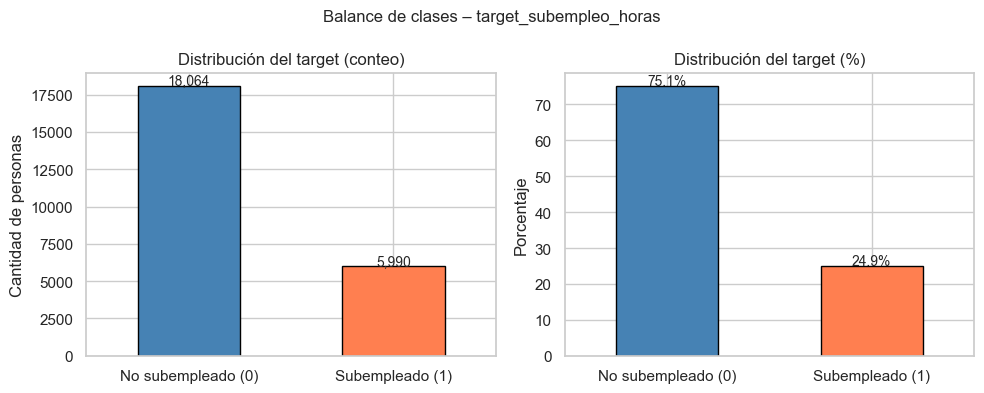

In [7]:
conteo = df_target['target_subempleo_horas'].value_counts().sort_index()
pct    = conteo / conteo.sum() * 100

tabla_dist = pd.DataFrame({
    'Clase':       [0, 1],
    'Significado': ['No subempleado por horas', 'Subempleado por horas'],
    'Conteo':      [conteo[0], conteo[1]],
    'Porcentaje':  [f'{pct[0]:.1f}%', f'{pct[1]:.1f}%'],
})
print(tabla_dist.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

etiquetas = ['No subempleado (0)', 'Subempleado (1)']
colores   = ['steelblue', 'coral']

conteo_plot = conteo.copy()
conteo_plot.index = etiquetas
conteo_plot.plot(kind='bar', ax=axes[0], color=colores, edgecolor='black', rot=0)
axes[0].set_title('Distribución del target (conteo)')
axes[0].set_ylabel('Cantidad de personas')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10)

pct_plot = pct.copy()
pct_plot.index = etiquetas
pct_plot.plot(kind='bar', ax=axes[1], color=colores, edgecolor='black', rot=0)
axes[1].set_title('Distribución del target (%)')
axes[1].set_ylabel('Porcentaje')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.suptitle('Balance de clases – target_subempleo_horas', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Interpretación de la distribución

- La **clase 0** (no subempleado) representa aproximadamente el **75.1 %** del universo analítico.
- La **clase 1** (subempleado por horas) representa aproximadamente el **24.9 %**.
- Esto indica un **desbalance moderado**, pero no extremo (no es un caso de 95/5 o similar).
- Por ello, en etapas posteriores se evaluará el uso de:
  - `class_weight='balanced'` en los modelos de clasificación.
  - Técnicas de **oversampling** (SMOTE) o **undersampling** (RandomUnderSampler).
  - Métricas robustas al desbalance: F1-score, AUC-ROC, precision-recall.

## 8. Variables con riesgo de data leakage

Las variables `C333`, `C334` y la propia `P209H` **no deben usarse como predictoras** del modelo:

| Variable | Descripción | Motivo de exclusión |
|---|---|---|
| `P209H` | Subempleo por horas (condición combinada) | **Es el target mismo** |
| `C333` | ¿Quería trabajar más horas? | Componente directo del target — filtra quienes sí quieren más horas |
| `C334` | ¿Estaba disponible para trabajar más horas? | Componente directo del target — filtra quienes están disponibles |

Incluir cualquiera de estas variables en el modelo causaría **data leakage**, ya que el modelo aprendería trivialmente a predecir el target usando información que en la práctica se genera al mismo tiempo que él.

In [8]:
leakage_variables = ['P209H', 'C333', 'C334']
print('Variables excluidas por data leakage:')
for v in leakage_variables:
    print(f'  - {v}')

Variables excluidas por data leakage:
  - P209H
  - C333
  - C334


## 9. Guardar dataset con target definido

In [9]:
OUTPUT_DIR  = Path(PROJECT_DIR) / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / 'epen_target_defined.csv'
df_target.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')

print(f'Archivo guardado en: {OUTPUT_PATH}')
print(f'Dimensiones guardadas: {df_target.shape[0]:,} filas × {df_target.shape[1]} columnas')

Archivo guardado en: g:\Mi unidad\UP - Ingeniería de la información\Semestre IX\Machine Learning\TrabajoFinal\clonProyecto\ML_PROYECTO_26_1\ml_project\data\processed\epen_target_defined.csv
Dimensiones guardadas: 24,054 filas × 136 columnas


## 10. Conclusiones

- Se definió formalmente `target_subempleo_horas` a partir de la variable `P209H` del cuestionario EPEN 2024.
- El **universo analítico** queda compuesto por residentes habituales de Lima Metropolitana, de 14 años a más y con condición de ocupados, que respondieron `P209H` (valores 1 o 2).
- El target presenta **dos clases**: subempleado por horas (1) y no subempleado por horas (0).
- Se identificó un **desbalance moderado** (~24.9 % clase 1 vs ~75.1 % clase 0), que deberá ser gestionado en la etapa de balanceo de clases.
- Las variables `P209H`, `C333` y `C334` quedan **excluidas del conjunto de predictores** por constituir data leakage directo del target.
- El archivo `epen_target_defined.csv` generado servirá como insumo para la etapa de preprocesamiento.